# Task 4 — ABC-MCMC experiments on different ABC methods and subsets

## References
- (1) Marjoram et al. (2003). Markov chain Monte Carlo without likelihoods. *PNAS*, 100(26).
- (2) Roberts & Rosenthal (2009). Examples of adaptive MCMC. *JCGS*, 18(2).
- (3) Fearnhead & Prangle (2012). Constructing summary statistics for ABC. *JRSS-B*, 74(3).
- (4) Blum et al. (2013). A comparative review of dimension reduction methods in ABC. *Statistical Science*, 28(2).

---
## Motivation

Rejection ABC is simulation-inefficient: acceptance rates decay as $\varepsilon \to 0$, wasting
computation on draws far from the posterior. In our rejection ABC experiments, operating at
$\delta = 1\%$ yielded only 100 accepted draws from $M = 10{,}000$ prior simulations — the
majority of computation was spent on rejected proposals. Regression adjustment and synthetic
likelihood partially address the bias introduced by finite $\varepsilon$: regression adjustment
applies a local linear correction to the accepted draws post hoc, while synthetic likelihood
replaces the indicator $\mathbf{1}[\rho \leq \varepsilon]$ with a Gaussian approximation to
$p(S(x) \mid \theta)$, avoiding the need for $\varepsilon$ entirely. However, both methods
remain tied to the initial set of prior draws — they cannot adaptively concentrate simulation
effort in high-posterior regions.

ABC-MCMC [(1)](#references) addresses this by constructing a Markov chain targeting the ABC
posterior

$$\pi_\varepsilon(\theta \mid x_{\text{obs}}) \propto \pi(\theta) \int \mathbf{1}\bigl[\rho(S(x), S(x_{\text{obs}})) \leq \varepsilon\bigr]\, p(x \mid \theta)\, dx,$$

using a Metropolis–Hastings kernel that proposes locally from the current state, concentrating
simulation effort in high-posterior regions. This yields a valid sample from
$\pi_\varepsilon(\theta \mid x_{\text{obs}})$ without requiring the acceptance rate to scale
with the prior volume. The key tradeoff relative to rejection ABC is that chain samples are
autocorrelated — requiring convergence diagnostics and burn-in — whereas rejection ABC produces
independent draws. Relative to synthetic likelihood, ABC-MCMC makes no distributional assumption
on $S(x \mid \theta)$, making it more robust when summary statistics are non-Gaussian.

---

## Methods

### Summary Statistics and Tolerance (refer to Rejection ABC)

Simulator outputs are compressed into $S(x) \in \mathbb{R}^p$. Distances are normalised by component-wise prior standard deviations $\hat{\sigma}$:

$$\rho(S(x), S(x_{\text{obs}})) = \left\| \frac{S(x) - S(x_{\text{obs}})}{\hat{\sigma}} \right\|_2.$$

Three summary sets are compared: **balanced** ($p=15$), **LASSO-selected** [(4)](#references),
and **semi-automatic** [(3)](#references), which projects to $\hat{S}(x) \in \mathbb{R}^3$ via
ridge regression on prior simulation pairs. The tolerance $\varepsilon$ is set to the $1\%$
quantile of prior distances, recalibrated separately for the semi-automatic variant.

### MCMC Algorithm

The chain proposes $\theta^* = \theta_t + \eta$, $\eta \sim \mathcal{N}(0, \Sigma)$, simulates
$R = 40$ replicates, and accepts via

$$\theta_{t+1} = \begin{cases} \theta^* & \text{if } \rho(S(x^*), S(x_{\text{obs}})) \leq \varepsilon \text{ and } u \leq \dfrac{\pi(\theta^*)}{\pi(\theta_t)}, \\ \theta_t & \text{otherwise,} \end{cases}$$

where $u \sim \mathcal{U}(0,1)$. Under a uniform prior the MH ratio reduces to 1 within the
prior support. The proposal covariance is then tuned via optimal scaling
$\Sigma^* = \frac{2.38^2}{d}\,\text{Cov}(\{\theta_t\})$ [(2)](#references) until an acceptable trade-off between acceptance rate and mixing is achieved.

### Workflow

1. **Import inputs.** Load tolerance $\varepsilon$, normalisation constants $\hat{\sigma}$,
prior distances $\{\rho_i\}_{i=1}^{M}$, semi-automatic projection model $B$, projected
tolerance $\varepsilon_{\text{semi-auto}}$, and LASSO-selected feature indices from the
rejection ABC notebook.
2. **Initialise chain.** Select $\theta_0$ from the accepted prior draws
$\{\theta_i : \rho_i \leq \varepsilon\}$.
3. **Run chain.** Run three variants (balanced, LASSO, semi-automatic) for $N = 30{,}000$
steps, drawing $R = 40$ fresh simulations per proposal via `simulate_fast` (imported from simulator).
Discard the first $b = 1{,}000$ steps as burn-in.
4. **Diagnose.** Assess convergence via split-chain $\hat{R}$ [(2)](#references) and trace
plots. Compute optimal proposal scaling $\Sigma^* = \frac{2.38^2}{d}\,\text{Cov}(\{\theta_t\})$
[(2)](#references) and rerun chains with the updated input.

## 1. Inputs

In [57]:
# ── Imports ───────────────────────────────────────────────────────────
import sys
import importlib.util
import json
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

spec = importlib.util.spec_from_file_location("simulator", ROOT / "scripts" / "simulator.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
simulate_fast = mod.simulate_fast

obs_data = np.load(ROOT / "data" / "obs_data.npz")
obs_inf  = obs_data["obs_inf"]
obs_rew  = obs_data["obs_rew"]
obs_deg  = obs_data["obs_deg"]

data      = np.load(ROOT / "data" / "prior_simulations.npz")
thetas    = data["thetas"]
sim_inf   = data["infected_fractions"]
sim_rew   = data["rewire_counts"]
sim_deg   = data["degree_histograms"]

# ── Degree distribution helpers ───────────────────────────────────────────────
DEGREES = np.arange(31, dtype=float)

def _degree_mean(deg):   # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    return ((deg * DEGREES).sum(axis=2, keepdims=True) / total).mean(axis=1)

def _degree_std(deg):    # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    mu  = (deg * DEGREES).sum(axis=2) / total.squeeze(2)
    mu2 = (deg * DEGREES**2).sum(axis=2) / total.squeeze(2)
    return np.sqrt((mu2 - mu**2).clip(min=0)).mean(axis=1, keepdims=True)

def _degree_entropy(deg):  # (M, R, 31) → (M, 1)
    """Shannon entropy of the degree distribution — sensitive to distribution shape."""
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    p = deg / total
    return -(p * np.log(p + 1e-10)).sum(axis=2).mean(axis=1, keepdims=True)

def _degree_quantile(deg, q):  # (M, R, 31) → (M, 1)
    """q-th quantile of the degree distribution, averaged over replicates."""
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    cdf = np.cumsum(deg / total, axis=2)          # (M, R, 31)
    return (cdf < q).sum(axis=2).astype(float).mean(axis=1, keepdims=True)

# ── Feature catalogue (scalar summaries only) ─────────────────────────────────
# All features reduce (M, R, …) → (M, 1), keeping dimensionality equal across
# modalities so no single group dominates the Euclidean distance.

FEATURE_FUNCS = {
    # --- infection ---
    "peak_inf":          lambda i, w, d: np.max(i, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_inf":  lambda i, w, d: np.argmax(i, axis=2).astype(float).mean(axis=1, keepdims=True),
    "final_inf":         lambda i, w, d: i[:, :, -1].mean(axis=1, keepdims=True),
    "total_inf":         lambda i, w, d: i.sum(axis=2).mean(axis=1, keepdims=True),
    "epidemic_duration": lambda i, w, d: (i > 0.01).sum(axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_peak_inf":      lambda i, w, d: np.max(i, axis=2).std(axis=1, keepdims=True),
    "std_total_inf":     lambda i, w, d: i.sum(axis=2).std(axis=1, keepdims=True),
    # --- rewiring ---
    "total_rew":         lambda i, w, d: w.sum(axis=2).mean(axis=1, keepdims=True),
    "peak_rew":          lambda i, w, d: np.max(w, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_rew":  lambda i, w, d: np.argmax(w, axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_total_rew":     lambda i, w, d: w.sum(axis=2).std(axis=1, keepdims=True),
    "std_peak_rew":      lambda i, w, d: np.max(w, axis=2).std(axis=1, keepdims=True),
    # --- degree histogram ---
    "mean_degree":       lambda i, w, d: _degree_mean(d),
    "std_degree":        lambda i, w, d: _degree_std(d),
    "degree_entropy":    lambda i, w, d: _degree_entropy(d),
    "degree_q25":        lambda i, w, d: _degree_quantile(d, 0.25),
    "degree_q50":        lambda i, w, d: _degree_quantile(d, 0.50),
    "degree_q75":        lambda i, w, d: _degree_quantile(d, 0.75),
    "isolated_frac":     lambda i, w, d: (d[:, :, 0] / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
    "high_degree_frac":  lambda i, w, d: (d[:, :, 20:].sum(axis=2) / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
}

# ── Summary sets (direct-distance ABC) ────────────────────────────────────────
SUMMARY_SETS = {
    "infection_only": [
        "peak_inf", "time_to_peak_inf", "final_inf", "total_inf",
    ],
    "rewiring_only": [
        "total_rew", "peak_rew", "time_to_peak_rew",
    ],
    "degree_only": [
        "mean_degree", "std_degree", "isolated_frac", "high_degree_frac",
    ],
    # "balanced": equal features per modality + informative additions.
    # epidemic_duration separates β from ρ (ρ can suppress without shortening
    # the epidemic). Cross-replicate rewiring variance is especially sensitive
    # to ρ. Degree entropy + quartiles capture distribution shape beyond mean/std.
    "balanced": [
        # infection — 5 scalars
        "peak_inf", "epidemic_duration", "total_inf", "std_peak_inf", "std_total_inf",
        # rewiring — 4 scalars (mean + variance)
        "total_rew", "peak_rew", "std_total_rew", "std_peak_rew",
        # degree — 6 scalars (shape + spread + tails)
        "mean_degree", "std_degree", "degree_entropy",
        "degree_q25", "degree_q50", "degree_q75",
    ],
}

# ── Active set for direct-distance rejection ABC ──────────────────────────────
ACTIVE_SET = "balanced"

print(f"Active set: '{ACTIVE_SET}' ({len(SUMMARY_SETS[ACTIVE_SET])} features)")
for s, feats in SUMMARY_SETS.items():
    print(f"  {s:15s}: {len(feats):2d} features")

def compute_summaries(inf, rew, deg, feature_set=ACTIVE_SET):
    """Compute summary statistics for a batch or single observation.

    Parameters
    ----------
    inf : (M, R, T+1) or (R, T+1)
    rew : (M, R, T+1) or (R, T+1)
    deg : (M, R, 31)  or (R, 31)

    Returns
    -------
    (M, n_features) or (n_features,) for a single observation
    """
    squeeze = inf.ndim == 2
    if squeeze:
        inf, rew, deg = inf[np.newaxis], rew[np.newaxis], deg[np.newaxis]
    rew = rew.astype(float)
    deg = deg.astype(float)

    parts = []
    for name in SUMMARY_SETS[feature_set]:
        feat = FEATURE_FUNCS[name](inf, rew, deg)   # (M,) or (M, k)
        if feat.ndim == 1:
            feat = feat[:, np.newaxis]
        parts.append(feat)

    result = np.concatenate(parts, axis=1)           # (M, n_features)
    return result[0] if squeeze else result

sim_stats = compute_summaries(sim_inf, sim_rew, sim_deg)    # (M, n_features)
obs_stats = compute_summaries(obs_inf, obs_rew, obs_deg)    # (n_features,)

# ── Load rejection ABC + semi-auto + LASSO outputs ───────────────────
abc_out   = np.load(ROOT / "data" / "abc_rejection_outputs.npz")
epsilon   = float(abc_out["epsilon"])
feat_std  = abc_out["feat_std"]
distances = abc_out["distances"]

sabc_out            = np.load(ROOT / "data" / "abc_semiauto_outputs.npz")
obs_stats_projected = sabc_out["obs_stats_projected"]
proj_std            = sabc_out["proj_std"]
reg                 = joblib.load(ROOT / "scripts" / "ridge.pkl")
epsilon_semiauto    = float(sabc_out["epsilon_semiauto"])

with open(ROOT / "data" / "lasso_selected_features.json") as f:
    selected_features = json.load(f)["selected_features"]

print(f"ε = {epsilon:.4f}")
print(f"ε (semi-auto) = {epsilon_semiauto:.4f}")
print(f"Selected features: {selected_features}")

Active set: 'balanced' (15 features)
  infection_only :  4 features
  rewiring_only  :  3 features
  degree_only    :  4 features
  balanced       : 15 features
ε = 1.2852
ε (semi-auto) = 0.3687
Selected features: ['peak_inf', 'epidemic_duration', 'total_inf', 'std_peak_inf', 'std_total_inf', 'total_rew', 'peak_rew', 'std_total_rew', 'std_peak_rew', 'mean_degree', 'std_degree', 'degree_entropy', 'degree_q25', 'degree_q50', 'degree_q75']


In [24]:
# ── Config ────────────────────────────────────────────────────────────
PRIOR_LOW   = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH  = np.array([0.50, 0.20, 0.8])
N_STEPS     = 30_000
R           = 40
PROPOSAL_SD = np.array([0.02, 0.005, 0.03])
SEED        = 42

rng = np.random.default_rng(SEED)

# ── Helpers ───────────────────────────────────────────────────────────
def in_prior(theta):
    return np.all(theta >= PRIOR_LOW) and np.all(theta <= PRIOR_HIGH)

# Variant 1: balanced
def get_stats_balanced(theta, rng):
    results = [simulate_fast(*theta, rng=rng) for _ in range(R)]
    inf = np.array([r[0] for r in results])[np.newaxis]
    rew = np.array([r[1] for r in results])[np.newaxis]
    deg = np.array([r[2] for r in results])[np.newaxis]
    return compute_summaries(inf, rew, deg, feature_set="balanced")[0]

def distance_balanced(s):
    return np.linalg.norm((s - obs_stats) / feat_std)

# Variant 2: LASSO
lasso_idx     = [list(SUMMARY_SETS["balanced"]).index(f) for f in selected_features]
obs_stats_las = obs_stats[lasso_idx]
feat_std_las  = feat_std[lasso_idx]

def get_stats_lasso(theta, rng):
    return get_stats_balanced(theta, rng)[lasso_idx]

def distance_lasso(s):
    return np.linalg.norm((s - obs_stats_las) / feat_std_las)

# Variant 3: semi-auto
def get_stats_semiauto(theta, rng):
    raw = get_stats_balanced(theta, rng)
    return reg.predict(raw.reshape(1, -1))[0]

def distance_semiauto(s):
    return np.linalg.norm((s - obs_stats_projected) / proj_std)

## 2. Initialise MCMC Chain

In [36]:
def run_mcmc(get_stats_fn, distance_fn, label, eps=None, proposal_sd=None):
    if eps is None:
        eps = epsilon
    if proposal_sd is None:
        proposal_sd = PROPOSAL_SD
    accepted_mask = distances <= epsilon
    current_theta = thetas[accepted_mask][0].copy()
    current_dist  = distance_fn(get_stats_fn(current_theta, rng))
    print(f"\n── {label} ──")
    print(f"Start: β={current_theta[0]:.3f}  γ={current_theta[1]:.3f}  ρ={current_theta[2]:.3f}")
    print(f"ε = {eps:.4f}  proposal_sd = {proposal_sd}")

    chain    = np.empty((N_STEPS, 3))
    accepted = 0

    for step in range(N_STEPS):
        proposed_theta = current_theta + rng.normal(0, proposal_sd)

        if not in_prior(proposed_theta):
            chain[step] = current_theta
            continue

        proposed_dist = distance_fn(get_stats_fn(proposed_theta, rng))

        if proposed_dist < eps:
            current_theta = proposed_theta
            current_dist  = proposed_dist
            accepted += 1

        chain[step] = current_theta

        if step % 500 == 0:
            rate = accepted / max(step, 1)
            print(f"[{step:5d}/{N_STEPS}]  accept={rate:.1%}  d={current_dist:.4f}  "
                  f"β={current_theta[0]:.3f}  γ={current_theta[1]:.3f}  ρ={current_theta[2]:.3f}")

    print(f"Final acceptance rate: {accepted / N_STEPS:.1%}")
    return chain

## 3. Run MCMC Chain

### 3.1 Standard MCMC Chain (not adaptive)

In [26]:
# ── Run balanced ─────────────────────────────────────────────────────
chain_balanced = run_mcmc(get_stats_balanced, distance_balanced, "Balanced")

# ── Run LASSO ────────────────────────────────────────────────────────
chain_lasso = run_mcmc(get_stats_lasso, distance_lasso, "LASSO")

# ── Run semi-auto ────────────────────────────────────────────────────
chain_semiauto = run_mcmc(get_stats_semiauto, distance_semiauto, "Semi-auto", eps=epsilon_semiauto)


── Balanced ──
Start: β=0.211  γ=0.122  ρ=0.403
ε = 1.2852
[    0/30000]  accept=0.0%  d=1.8077  β=0.211  γ=0.122  ρ=0.403
[  500/30000]  accept=17.4%  d=1.1259  β=0.205  γ=0.102  ρ=0.364
[ 1000/30000]  accept=18.7%  d=1.2078  β=0.314  γ=0.101  ρ=0.323
[ 1500/30000]  accept=15.6%  d=1.1252  β=0.265  γ=0.110  ρ=0.352
[ 2000/30000]  accept=16.2%  d=0.9765  β=0.140  γ=0.101  ρ=0.301
[ 2500/30000]  accept=17.4%  d=1.2075  β=0.196  γ=0.067  ρ=0.286
[ 3000/30000]  accept=16.6%  d=0.9893  β=0.203  γ=0.105  ρ=0.326
[ 3500/30000]  accept=16.8%  d=0.8930  β=0.083  γ=0.068  ρ=0.196
[ 4000/30000]  accept=17.1%  d=1.1125  β=0.283  γ=0.101  ρ=0.363
[ 4500/30000]  accept=17.4%  d=0.8810  β=0.208  γ=0.101  ρ=0.338
[ 5000/30000]  accept=17.5%  d=1.2258  β=0.145  γ=0.103  ρ=0.320
[ 5500/30000]  accept=17.4%  d=1.0252  β=0.107  γ=0.059  ρ=0.228
[ 6000/30000]  accept=17.9%  d=1.2369  β=0.183  γ=0.057  ρ=0.359
[ 6500/30000]  accept=18.2%  d=1.2708  β=0.135  γ=0.063  ρ=0.210
[ 7000/30000]  accept=17.9%  d=

[0.19607116 0.11049816 0.35401141]
[0.26976803 0.11615855 0.36421309]
[0.14387104 0.12004235 0.31206888]

                    β        γ        ρ
prior std      0.1299   0.0520   0.2309
balanced       0.0623   0.0214   0.0648  (rel: 0.48 0.41 0.28)
LASSO          0.0650   0.0206   0.0662  (rel: 0.50 0.40 0.29)
semi-auto      0.0266   0.0331   0.0596  (rel: 0.20 0.64 0.26)


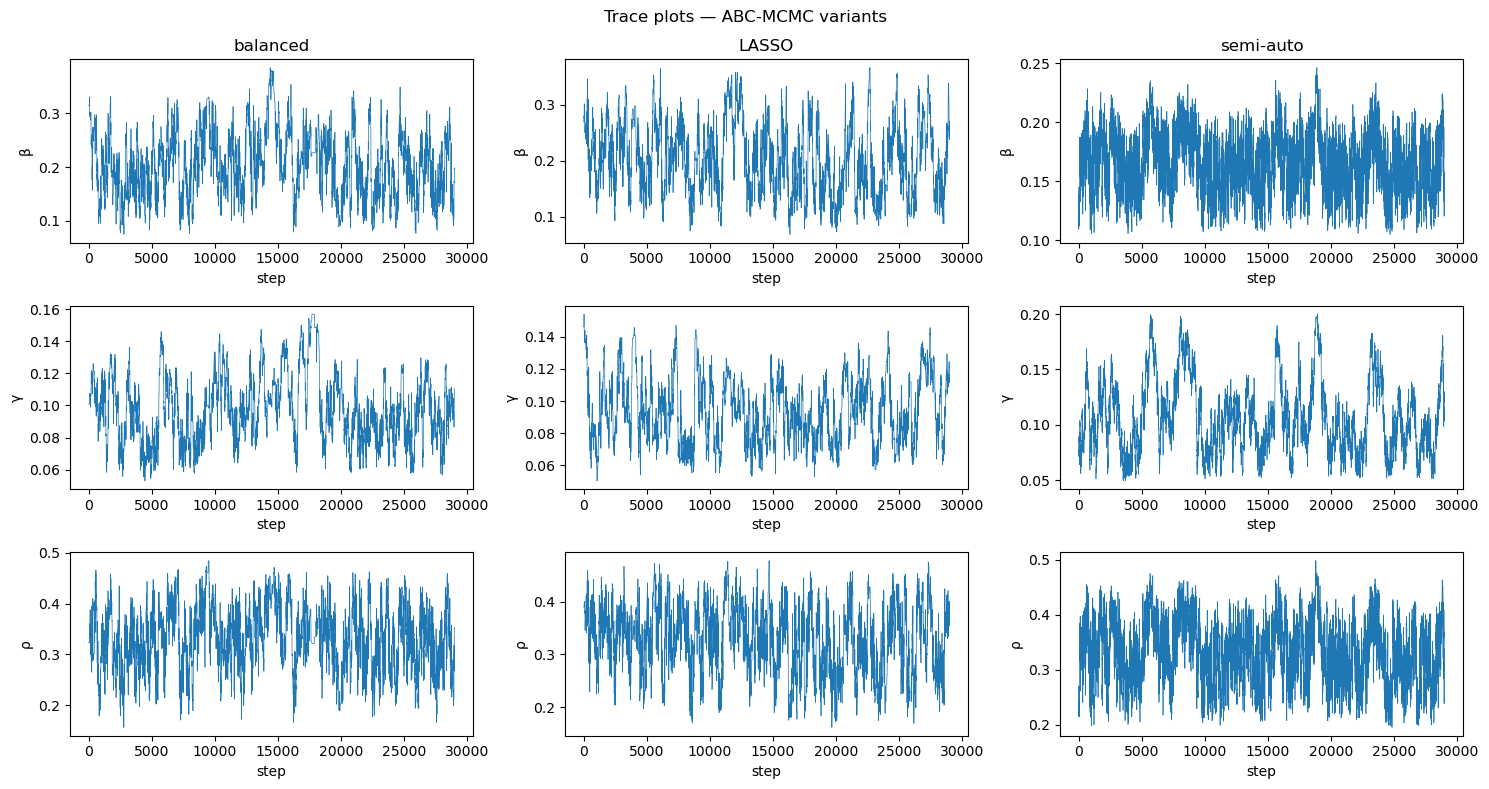

In [29]:
print(chain_balanced[-1])
print(chain_lasso[-1])
print(chain_semiauto[-1])

# ── Posterior width table ───────────────────────────────────────────
burn_in    = 1_000
labels     = ["β", "γ", "ρ"]
chains     = {"balanced": chain_balanced, "LASSO": chain_lasso, "semi-auto": chain_semiauto}
prior_std  = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)

print(f"\n{'':12s} {'β':>8} {'γ':>8} {'ρ':>8}")
print(f"{'prior std':12s} {prior_std[0]:>8.4f} {prior_std[1]:>8.4f} {prior_std[2]:>8.4f}")
for name, chain in chains.items():
    post = chain[burn_in:]
    stds = post.std(axis=0)
    rel  = stds / prior_std
    print(f"{name:12s} {stds[0]:>8.4f} {stds[1]:>8.4f} {stds[2]:>8.4f}  "
          f"(rel: {rel[0]:.2f} {rel[1]:.2f} {rel[2]:.2f})")
    
# ── Trace plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for col, (name, chain) in enumerate(chains.items()):
    for row, param in enumerate(labels):
        axes[row, col].plot(chain[burn_in:, row], lw=0.5)
        axes[row, col].set_ylabel(param)
        axes[row, col].set_xlabel("step")
        if row == 0:
            axes[row, col].set_title(name)
plt.suptitle("Trace plots — ABC-MCMC variants")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_traces.png", dpi=150, bbox_inches="tight")
plt.show()

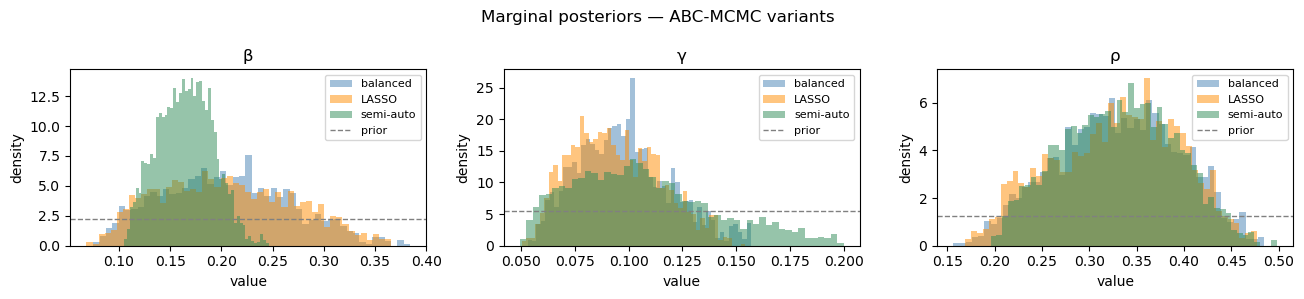

In [30]:
# ── Marginal posteriors ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
colors = {"balanced": "steelblue", "LASSO": "darkorange", "semi-auto": "seagreen"}
for col, param in enumerate(labels):
    for name, chain in chains.items():
        axes[col].hist(chain[burn_in:, col], bins=50, density=True,
                       alpha=0.5, color=colors[name], label=name)
    axes[col].axhline(1 / (PRIOR_HIGH[col] - PRIOR_LOW[col]),
                      color="grey", ls="--", lw=1, label="prior")
    axes[col].set(title=param, xlabel="value", ylabel="density")
    axes[col].legend(fontsize=8)
plt.suptitle("Marginal posteriors — ABC-MCMC variants")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_posteriors.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# ── Gelman-Rubin (split-chain approximation) ───────────────────────
def gelman_rubin(chains_list, burn_in=0):
    chains_post = np.array([c[burn_in:] for c in chains_list])  # (M, N, 3)
    M, N, D     = chains_post.shape
    chain_means = chains_post.mean(axis=1)
    grand_mean  = chain_means.mean(axis=0)
    B = N / (M - 1) * np.sum((chain_means - grand_mean)**2, axis=0)
    W = np.mean(chains_post.var(axis=1, ddof=1), axis=0)
    var_hat = (N - 1) / N * W + B / N
    return np.sqrt(var_hat / W)

labels    = ["β", "γ", "ρ"]
burn_in   = 1000
print("Gelman-Rubin R̂ (split-chain, want < 1.1):")
for name, chain in chains.items():
    half  = (N_STEPS - burn_in) // 2
    post  = chain[burn_in:]
    R_hat = gelman_rubin([post[:half], post[half:]])
    status = "✓" if np.all(R_hat < 1.1) else "✗"
    print(f"  {name:12s}  β={R_hat[0]:.4f}  γ={R_hat[1]:.4f}  ρ={R_hat[2]:.4f}  {status}")

Gelman-Rubin R̂ (split-chain, want < 1.1):
  balanced      β=1.0029  γ=1.0061  ρ=1.0014  ✓
  LASSO         β=1.0353  γ=1.0000  ρ=1.0317  ✓
  semi-auto     β=1.0018  γ=1.0048  ρ=1.0027  ✓


In [35]:
# ── Adaptive proposal kernel diagnostic ────────────────────────────
print("Optimal PROPOSAL_SD per variant (Roberts & Rosenthal 2.38/sqrt(d)):")
print(f"{'':12s}  {'β':>8} {'γ':>8} {'ρ':>8}")
print(f"{'current':12s}  {PROPOSAL_SD[0]:>8.4f} {PROPOSAL_SD[1]:>8.4f} {PROPOSAL_SD[2]:>8.4f}")
for name, chain in chains.items():
    post    = chain[burn_in:]
    cov     = np.cov(post.T)
    opt_sd  = np.sqrt(np.diag(cov)) * 2.38 / np.sqrt(3)
    print(f"  {name:12s}  {opt_sd[0]:>8.4f} {opt_sd[1]:>8.4f} {opt_sd[2]:>8.4f}")

Optimal PROPOSAL_SD per variant (Roberts & Rosenthal 2.38/sqrt(d)):
                     β        γ        ρ
current         0.0200   0.0050   0.0300
  balanced        0.0855   0.0295   0.0890
  LASSO           0.0893   0.0283   0.0910
  semi-auto       0.0365   0.0455   0.0819


### 3.2 Adaptive (optimal) MCMC chain

Re-run chain using optimal `PROPOSAL_SD` to improve mixing.

In [37]:
PROPOSAL_SD_balanced  = np.array([0.0855, 0.0295, 0.0890])
PROPOSAL_SD_lasso     = np.array([0.0893, 0.0283, 0.0910])
PROPOSAL_SD_semiauto  = np.array([0.0365, 0.0455, 0.0819])

chain_balanced_adaptive  = run_mcmc(get_stats_balanced,  distance_balanced,  
                                    "Balanced (adaptive)",  proposal_sd=PROPOSAL_SD_balanced)
chain_lasso_adaptive     = run_mcmc(get_stats_lasso,     distance_lasso,     
                                    "LASSO (adaptive)",     proposal_sd=PROPOSAL_SD_lasso)
chain_semiauto_adaptive  = run_mcmc(get_stats_semiauto,  distance_semiauto,  
                                    "Semi-auto (adaptive)", proposal_sd=PROPOSAL_SD_semiauto, 
                                    eps=epsilon_semiauto)


── Balanced (adaptive) ──
Start: β=0.211  γ=0.122  ρ=0.403
ε = 1.2852  proposal_sd = [0.0855 0.0295 0.089 ]
[    0/30000]  accept=0.0%  d=1.5068  β=0.211  γ=0.122  ρ=0.403
[  500/30000]  accept=5.2%  d=1.1266  β=0.240  γ=0.105  ρ=0.370
[ 1000/30000]  accept=5.0%  d=1.2564  β=0.188  γ=0.148  ρ=0.345
[ 1500/30000]  accept=4.7%  d=1.1365  β=0.172  γ=0.092  ρ=0.270
[ 2000/30000]  accept=4.7%  d=1.1128  β=0.183  γ=0.114  ρ=0.305
[ 2500/30000]  accept=4.5%  d=0.8617  β=0.147  γ=0.083  ρ=0.344
[ 3000/30000]  accept=4.6%  d=0.9180  β=0.176  γ=0.088  ρ=0.356
[ 3500/30000]  accept=4.7%  d=0.7006  β=0.205  γ=0.073  ρ=0.352
[ 4000/30000]  accept=4.8%  d=0.7900  β=0.149  γ=0.071  ρ=0.290
[ 4500/30000]  accept=4.9%  d=0.9146  β=0.149  γ=0.071  ρ=0.309
[ 5000/30000]  accept=5.1%  d=1.1926  β=0.116  γ=0.077  ρ=0.207
[ 5500/30000]  accept=4.9%  d=0.8798  β=0.213  γ=0.089  ρ=0.301
[ 6000/30000]  accept=5.1%  d=1.2715  β=0.121  γ=0.103  ρ=0.215
[ 6500/30000]  accept=5.1%  d=1.1367  β=0.206  γ=0.118  ρ=0

In [41]:
# ── Posterior width table (adaptive) ─────────────────────────────────────────
print(chain_balanced_adaptive[-1])
print(chain_lasso_adaptive[-1])
print(chain_semiauto_adaptive[-1])

burn_in    = 1_000
labels     = ["β", "γ", "ρ"]
chains_adaptive = {
    "balanced":  chain_balanced_adaptive,
    "LASSO":     chain_lasso_adaptive,
    "semi-auto": chain_semiauto_adaptive
}
prior_std  = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)

print(f"\n{'':12s} {'β':>8} {'γ':>8} {'ρ':>8}")
print(f"{'prior std':12s} {prior_std[0]:>8.4f} {prior_std[1]:>8.4f} {prior_std[2]:>8.4f}")
for name, chain in chains_adaptive.items():
    post = chain[burn_in:]
    stds = post.std(axis=0)
    rel  = stds / prior_std
    print(f"{name:12s} {stds[0]:>8.4f} {stds[1]:>8.4f} {stds[2]:>8.4f}  "
          f"(rel: {rel[0]:.2f} {rel[1]:.2f} {rel[2]:.2f})")

[0.13822058 0.08480738 0.25920774]
[0.22693754 0.13053462 0.35713403]
[0.16789797 0.06817657 0.32542407]

                    β        γ        ρ
prior std      0.1299   0.0520   0.2309
balanced       0.0666   0.0212   0.0658  (rel: 0.51 0.41 0.28)
LASSO          0.0630   0.0222   0.0634  (rel: 0.49 0.43 0.27)
semi-auto      0.0267   0.0374   0.0606  (rel: 0.21 0.72 0.26)


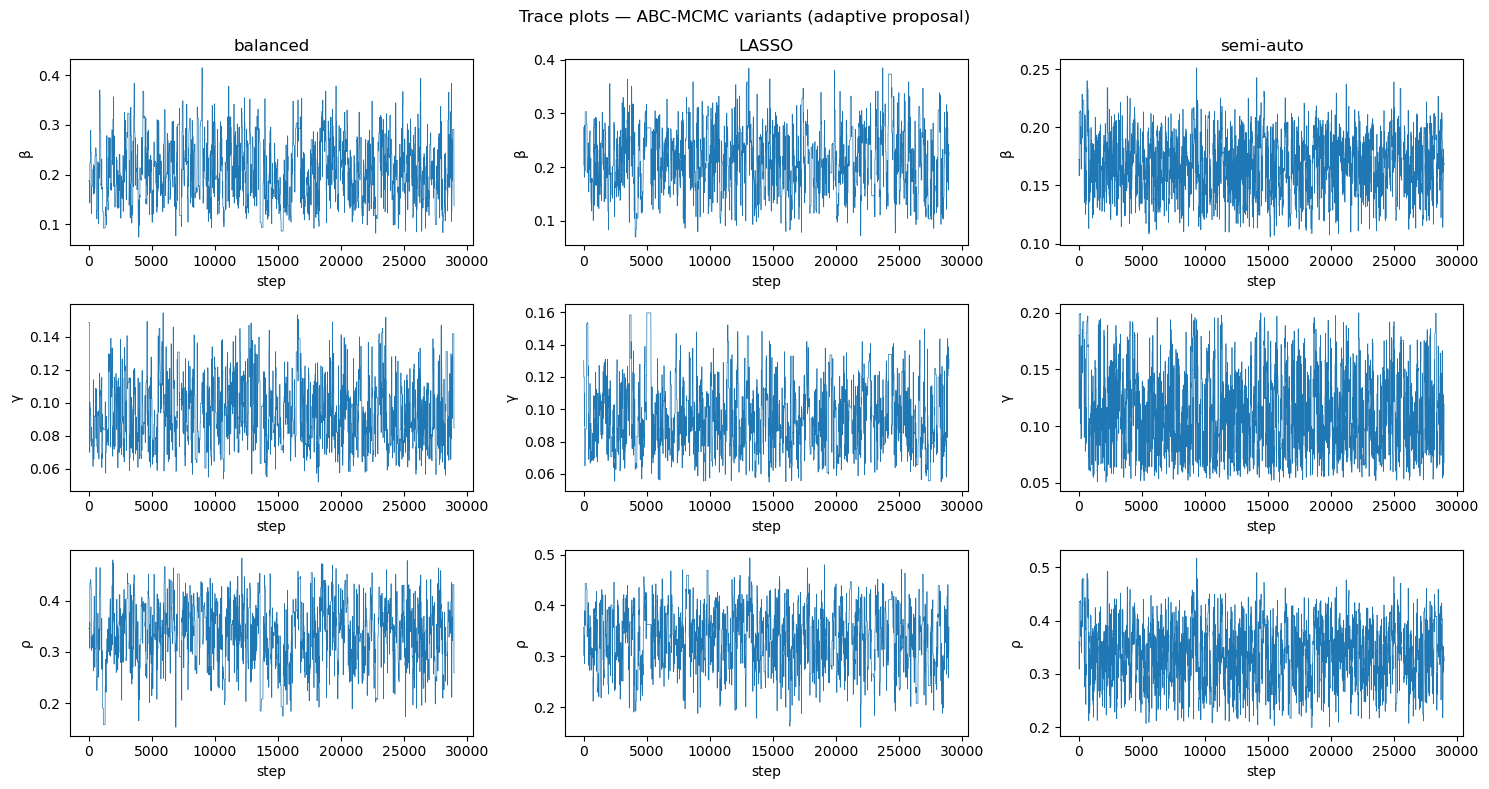

In [53]:
# ── Trace plots (adaptive) ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for col, (name, chain) in enumerate(chains_adaptive.items()):
    for row, param in enumerate(labels):
        axes[row, col].plot(chain[burn_in:, row], lw=0.5)
        axes[row, col].set_ylabel(param)
        axes[row, col].set_xlabel("step")
        if row == 0:
            axes[row, col].set_title(name)
plt.suptitle("Trace plots — ABC-MCMC variants (adaptive proposal)")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_traces_adaptive.png", dpi=150, bbox_inches="tight")
plt.show()

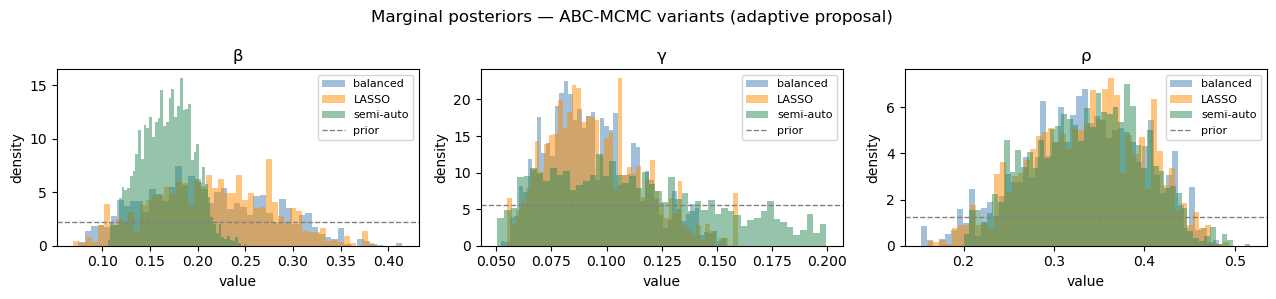

In [54]:
# ── Marginal posteriors (adaptive) ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
colors = {"balanced": "steelblue", "LASSO": "darkorange", "semi-auto": "seagreen"}
for col, param in enumerate(labels):
    for name, chain in chains_adaptive.items():
        axes[col].hist(chain[burn_in:, col], bins=50, density=True,
                       alpha=0.5, color=colors[name], label=name)
    axes[col].axhline(1 / (PRIOR_HIGH[col] - PRIOR_LOW[col]),
                      color="grey", ls="--", lw=1, label="prior")
    axes[col].set(title=param, xlabel="value", ylabel="density")
    axes[col].legend(fontsize=8)
plt.suptitle("Marginal posteriors — ABC-MCMC variants (adaptive proposal)")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_posteriors_adaptive.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Gelman-Rubin (adaptive) ───────────────────────────────────────────────────
print("Gelman-Rubin R̂ (split-chain, want < 1.1):")
for name, chain in chains_adaptive.items():
    half  = (N_STEPS - burn_in) // 2
    post  = chain[burn_in:]
    R_hat = gelman_rubin([post[:half], post[half:]])
    status = "✓" if np.all(R_hat < 1.1) else "✗"
    print(f"  {name:12s}  β={R_hat[0]:.4f}  γ={R_hat[1]:.4f}  ρ={R_hat[2]:.4f}  {status}")

Gelman-Rubin R̂ (split-chain, want < 1.1):
  balanced      β=1.0011  γ=1.0009  ρ=1.0036  ✓
  LASSO         β=1.0008  γ=1.0022  ρ=1.0051  ✓
  semi-auto     β=1.0009  γ=1.0002  ρ=1.0008  ✓


### 3.3 0.5x balanced adaptive MCMC chain
Optimal `PROPOSAL_SD` yields lower acceptance rates but better mixing. Compromise by halving to have improved mixing and acceptable acceptance rates. Use these for SMC.

In [46]:
# ── Run balanced (adaptive proposal 0.5x) ──────────────────────────
PROPOSAL_SD_balanced_half = np.array([0.0855, 0.0295, 0.0890]) * 0.5
chain_balanced_adaptive2 = run_mcmc(get_stats_balanced, distance_balanced,
                                    "Balanced (adaptive 0.5x)",
                                    proposal_sd=PROPOSAL_SD_balanced_half)
# ── Run LASSO (adaptive proposal 0.5x) ──────────────────────────────
PROPOSAL_SD_lasso_half = np.array([0.0893, 0.0283, 0.0910]) * 0.5
chain_lasso_adaptive2 = run_mcmc(get_stats_lasso, distance_lasso,
                                 "LASSO (adaptive 0.5x)",
                                 proposal_sd=PROPOSAL_SD_lasso_half)
# ── Run semi-auto (adaptive proposal 0.5x) ─────────────────────────
PROPOSAL_SD_semiauto_half = np.array([0.0365, 0.0455, 0.0819]) * 0.5
chain_semiauto_adaptive2 = run_mcmc(get_stats_semiauto, distance_semiauto,
                                    "Semi-auto (adaptive 0.5x)",
                                    proposal_sd=PROPOSAL_SD_semiauto_half,
                                    eps=epsilon_semiauto)


── Balanced (adaptive 0.5x) ──
Start: β=0.211  γ=0.122  ρ=0.403
ε = 1.2852  proposal_sd = [0.04275 0.01475 0.0445 ]
[    0/30000]  accept=100.0%  d=1.0590  β=0.289  γ=0.105  ρ=0.394
[  500/30000]  accept=4.6%  d=1.1688  β=0.299  γ=0.106  ρ=0.397
[ 1000/30000]  accept=8.5%  d=1.2659  β=0.171  γ=0.069  ρ=0.223
[ 1500/30000]  accept=9.1%  d=1.2311  β=0.142  γ=0.101  ρ=0.248
[ 2000/30000]  accept=10.0%  d=1.2771  β=0.312  γ=0.075  ρ=0.366
[ 2500/30000]  accept=10.7%  d=1.2040  β=0.153  γ=0.102  ρ=0.339
[ 3000/30000]  accept=10.9%  d=1.1611  β=0.093  γ=0.064  ρ=0.197
[ 3500/30000]  accept=11.5%  d=1.2625  β=0.214  γ=0.099  ρ=0.323
[ 4000/30000]  accept=11.4%  d=1.2814  β=0.217  γ=0.069  ρ=0.390
[ 4500/30000]  accept=11.6%  d=0.8804  β=0.151  γ=0.072  ρ=0.326
[ 5000/30000]  accept=11.5%  d=1.1603  β=0.240  γ=0.079  ρ=0.389
[ 5500/30000]  accept=11.7%  d=0.8687  β=0.157  γ=0.095  ρ=0.253
[ 6000/30000]  accept=11.4%  d=1.0262  β=0.272  γ=0.081  ρ=0.432
[ 6500/30000]  accept=11.6%  d=1.1924  β

In [68]:
# ── Posterior width table (adaptive 0.5x) ────────────────────────────────────
print(chain_balanced_adaptive2[-1])
print(chain_lasso_adaptive2[-1])
print(chain_semiauto_adaptive2[-1])

burn_in = 1_000
chains_adaptive2 = {
    "balanced":  chain_balanced_adaptive2,
    "LASSO":     chain_lasso_adaptive2,
    "semi-auto": chain_semiauto_adaptive2
}

print(f"\n{'':12s} {'β':>8} {'γ':>8} {'ρ':>8}")
print(f"{'prior std':12s} {prior_std[0]:>8.4f} {prior_std[1]:>8.4f} {prior_std[2]:>8.4f}")
for name, chain in chains_adaptive2.items():
    post = chain[burn_in:]
    stds = post.std(axis=0)
    rel  = stds / prior_std
    print(f"{name:12s} {stds[0]:>8.4f} {stds[1]:>8.4f} {stds[2]:>8.4f}  "
          f"(rel: {rel[0]:.2f} {rel[1]:.2f} {rel[2]:.2f})")

[0.13421536 0.0662741  0.25680142]
[0.20147439 0.08519191 0.3908044 ]
[0.19957448 0.09147962 0.41025151]

                    β        γ        ρ
prior std      0.1299   0.0520   0.2309
balanced       0.0626   0.0204   0.0665  (rel: 0.48 0.39 0.29)
LASSO          0.0700   0.0206   0.0691  (rel: 0.54 0.40 0.30)
semi-auto      0.0281   0.0376   0.0637  (rel: 0.22 0.72 0.28)


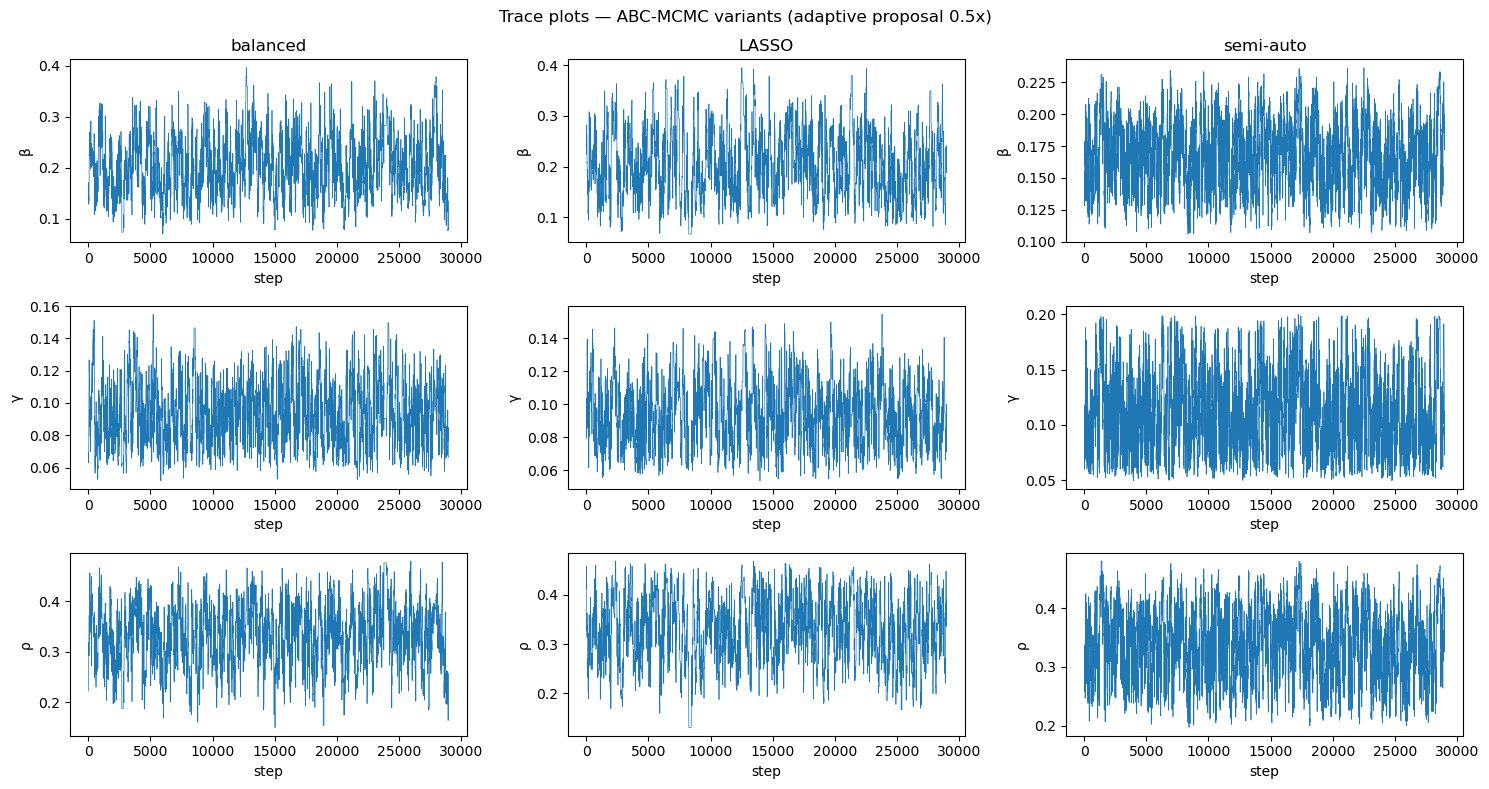

In [49]:
# ── Trace plots (adaptive) ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for col, (name, chain) in enumerate(chains_adaptive2.items()):
    for row, param in enumerate(labels):
        axes[row, col].plot(chain[burn_in:, row], lw=0.5)
        axes[row, col].set_ylabel(param)
        axes[row, col].set_xlabel("step")
        if row == 0:
            axes[row, col].set_title(name)
plt.suptitle("Trace plots — ABC-MCMC variants (adaptive proposal 0.5x)")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_traces_adaptive_0_5.png", dpi=150, bbox_inches="tight")
plt.show()

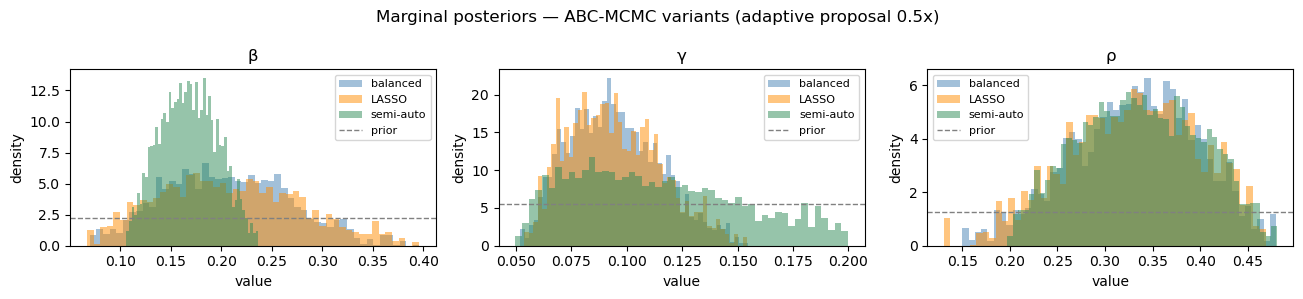

In [ ]:
# ── Marginal posteriors (adaptive 0.5x) ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
colors = {"balanced": "steelblue", "LASSO": "darkorange", "semi-auto": "seagreen"}
for col, param in enumerate(labels):
    for name, chain in chains_adaptive2.items():
        axes[col].hist(chain[burn_in:, col], bins=50, density=True,
                       alpha=0.5, color=colors[name], label=name)
    axes[col].axhline(1 / (PRIOR_HIGH[col] - PRIOR_LOW[col]),
                      color="grey", ls="--", lw=1, label="prior")
    axes[col].set(title=param, xlabel="value", ylabel="density")
    axes[col].legend(fontsize=8)
plt.suptitle("Marginal posteriors — ABC-MCMC variants (adaptive proposal 0.5x)")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_posteriors_adaptive_0_5.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Interpretation

In [63]:
# ── Acceptance rate + R̂ summary table ──────────────────────────────
burn_in      = 1_000
prior_std    = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)
version_data = {
    "original":      [chain_balanced,           chain_lasso,           chain_semiauto],
    "adaptive 1x":   [chain_balanced_adaptive,  chain_lasso_adaptive,  chain_semiauto_adaptive],
    "adaptive 0.5x": [chain_balanced_adaptive2, chain_lasso_adaptive2, chain_semiauto_adaptive2],
}

print(f"{'version':15s} {'variant':12s} {'R̂ β':>8} {'R̂ γ':>8} {'R̂ ρ':>8} {'status':>6}")
print("-" * 60)
for version_name, version_chains in version_data.items():
    for variant, chain in zip(variants, version_chains):
        half  = (N_STEPS - burn_in) // 2
        post  = chain[burn_in:]
        R_hat = gelman_rubin([post[:half], post[half:]])
        status = "✓" if np.all(R_hat < 1.1) else "✗"
        print(f"{version_name:15s} {variant:12s} {R_hat[0]:>8.4f} {R_hat[1]:>8.4f} {R_hat[2]:>8.4f} {status:>6}")
    print()

version         variant          R̂ β     R̂ γ     R̂ ρ status
------------------------------------------------------------
original        balanced       1.0029   1.0061   1.0014      ✓
original        LASSO          1.0353   1.0000   1.0317      ✓
original        semi-auto      1.0018   1.0048   1.0027      ✓

adaptive 1x     balanced       1.0011   1.0009   1.0036      ✓
adaptive 1x     LASSO          1.0008   1.0022   1.0051      ✓
adaptive 1x     semi-auto      1.0009   1.0002   1.0008      ✓

adaptive 0.5x   balanced       1.0003   1.0003   1.0002      ✓
adaptive 0.5x   LASSO          1.0011   1.0001   1.0000      ✓
adaptive 0.5x   semi-auto      1.0000   1.0002   1.0000      ✓



Adaptive 0.5x confirmed to be the best version with near 1 values indicating accurate posterior estimates and good mixing. Carry on with SMC using adaptive 0.5x.

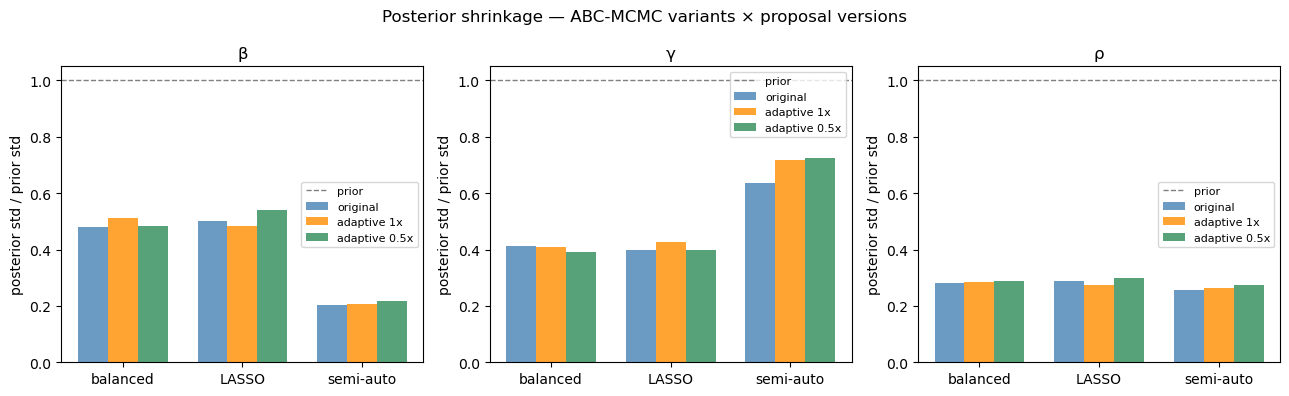

In [64]:
# ── Posterior width comparison — grouped bar chart ──────────────────
burn_in      = 1_000
prior_std    = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)
version_data = {
    "original":      [chain_balanced,           chain_lasso,           chain_semiauto],
    "adaptive 1x":   [chain_balanced_adaptive,  chain_lasso_adaptive,  chain_semiauto_adaptive],
    "adaptive 0.5x": [chain_balanced_adaptive2, chain_lasso_adaptive2, chain_semiauto_adaptive2],
}
colors_v = {"original": "steelblue", "adaptive 1x": "darkorange", "adaptive 0.5x": "seagreen"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
x = np.arange(len(variants))
width = 0.25

for ax, p_idx, param in zip(axes, range(3), labels):
    for v_idx, (version_name, version_chains) in enumerate(version_data.items()):
        stds = [c[burn_in:, p_idx].std() / prior_std[p_idx] for c in version_chains]
        ax.bar(x + v_idx * width, stds, width, label=version_name,
               color=colors_v[version_name], alpha=0.8)
    ax.axhline(1.0, color="grey", ls="--", lw=1, label="prior")
    ax.set_xticks(x + width)
    ax.set_xticklabels(variants)
    ax.set_ylabel("posterior std / prior std")
    ax.set_title(param)
    ax.legend(fontsize=8)

plt.suptitle("Posterior shrinkage — ABC-MCMC variants × proposal versions")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_width_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Summary set choice clearly most important aspect. Proposal tuning has minimal effect on posterior width, actually. 0.5x best tradeoff, but differences small.

Unfortunately, while semi-auto improves beta/rho, it performs worse for gamma. This is likely due to gamma being informed mostly by `infection_only` and `epidemic_duration`, so ridge regression likely sacrifices gamma in favour of beta/rho.

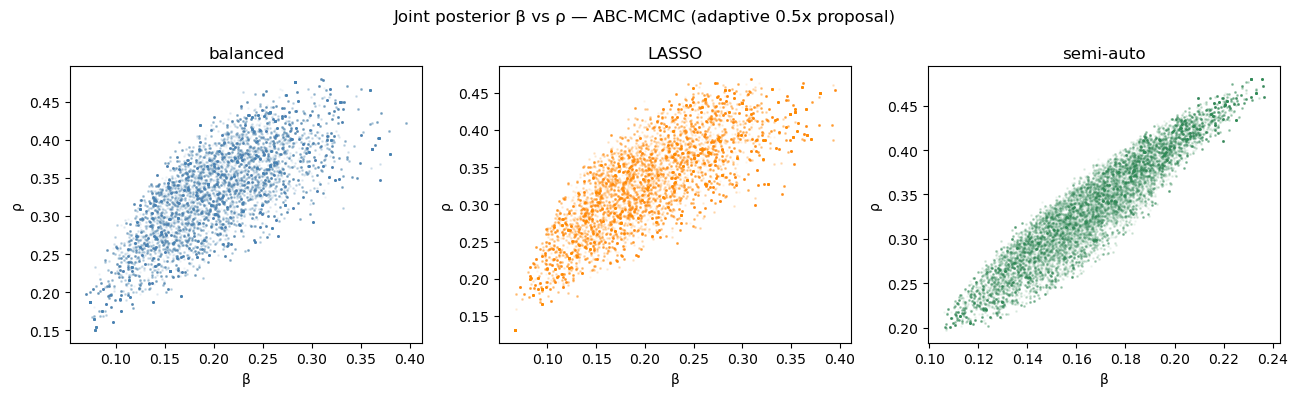

In [67]:
# ── Joint posterior β vs ρ (0.5x) ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, chain) in zip(axes, chains_best.items()):
    ax.scatter(chain[burn_in:, 0], chain[burn_in:, 2],
               alpha=0.05, s=1, color=colors[name])
    ax.set_xlabel("β")
    ax.set_ylabel("ρ")
    ax.set_title(name)
plt.suptitle("Joint posterior β vs ρ — ABC-MCMC (adaptive 0.5x proposal)")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "mcmc_joint_beta_rho.png", dpi=150, bbox_inches="tight")
plt.show()

Very strong beta-rho correlation, cloud is the narrowest and best-defined using semi-auto.

## Exports

In [60]:
# ── Exports for SMC ─────────────────────────────────────────────────────────
np.savez(ROOT / "data" / "smc_proposal.npz",
    PROPOSAL_SD_balanced  = PROPOSAL_SD_balanced_half,
    PROPOSAL_SD_lasso     = PROPOSAL_SD_lasso_half,
    PROPOSAL_SD_semiauto  = PROPOSAL_SD_semiauto_half,
)

# ── Save all chains ───────────────────────────────────────────────────────────
np.savez(ROOT / "data" / "mcmc_chains.npz",
    # original
    chain_balanced_orig      = chain_balanced,
    chain_lasso_orig         = chain_lasso,
    chain_semiauto_orig      = chain_semiauto,
    # adaptive 1x
    chain_balanced_adaptive  = chain_balanced_adaptive,
    chain_lasso_adaptive     = chain_lasso_adaptive,
    chain_semiauto_adaptive  = chain_semiauto_adaptive,
    # adaptive 0.5x (best)
    chain_balanced_best      = chain_balanced_adaptive2,
    chain_lasso_best         = chain_lasso_adaptive2,
    chain_semiauto_best      = chain_semiauto_adaptive2,
)